In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!rm -rf /content/drive/MyDrive/FIAP/Modulo_1/TechChallenge
!mkdir /content/drive/MyDrive/FIAP/Modulo_1/TechChallenge

In [3]:
# Mudar o diretório atual para sua pasta específica
%cd /content/drive/MyDrive/FIAP/Modulo_1/TechChallenge

/content/drive/MyDrive/FIAP/Modulo_1/TechChallenge


In [4]:
!pwd

/content/drive/MyDrive/FIAP/Modulo_1/TechChallenge


In [ ]:
# Geração de dados

In [5]:
import pandas as pd
import numpy as np

# Fixar semente para reprodutibilidade
np.random.seed(42)

# Tamanhos e opções
n = 2000
generos = ['masculino', 'feminino']
fumantes = ['sim', 'não']
regioes = ['nordeste', 'noroeste', 'sudeste', 'sudoeste']

def gerar_dados(n):
    idades = np.random.randint(18, 65, size=n)
    generos_rand = np.random.choice(generos, size=n)
    imcs = np.round(np.random.normal(loc=27, scale=5, size=n), 2)  # IMC médio realista
    filhos = np.random.randint(0, 5, size=n)
    fumantes_rand = np.random.choice(fumantes, size=n, p=[0.2, 0.8])  # 20% fumantes
    regioes_rand = np.random.choice(regioes, size=n)

    encargos = []
    for i in range(n):
        base = 2000
        idade = idades[i]
        imc = imcs[i]
        filhos_qtd = filhos[i]
        fumante = fumantes_rand[i]
        regiao = regioes_rand[i]

        # Fórmula base para custo
        custo = base + idade * 250 + imc * 200 + filhos_qtd * 500

        # Aumentar custo se for fumante
        if fumante == 'sim':
            custo *= 2.8

        # Pequena variação por região
        if regiao == 'nordeste':
            custo *= 1.0
        elif regiao == 'noroeste':
            custo *= 1.05
        elif regiao == 'sudeste':
            custo *= 1.1
        else:  # sudoeste
            custo *= 1.15

        # Ruído aleatório
        custo += np.random.normal(loc=0, scale=1000)
        encargos.append(round(custo, 2))

    # Criar DataFrame
    df = pd.DataFrame({
        'idade': idades,
        'gênero': generos_rand,
        'imc': imcs,
        'filhos': filhos,
        'fumante': fumantes_rand,
        'região': regioes_rand,
        'encargos': encargos
    })

    return df

# Gerar os dados
df_sintetico = gerar_dados(n=1000)

# Salvar em CSV
df_sintetico.to_csv('dados_seguro_sintetico.csv', index=False)
print(df_sintetico.head())

   idade     gênero    imc  filhos fumante    região  encargos
0     56  masculino  24.22       1     não   sudeste  22904.47
1     46   feminino  36.41       2     não  nordeste  22875.24
2     32   feminino  19.76       4     sim  noroeste  48803.31
3     60   feminino  16.01       4     não  nordeste  21596.61
4     25  masculino  29.20       3     sim  noroeste  46973.02


In [6]:
import pandas as pd
dataset = pd.read_csv("dados_seguro_sintetico.csv")

In [7]:
dataset.head()

,idade,gênero,imc,filhos,fumante,região,encargos
0,56,masculino,24.22,1,não,sudeste,22904.47
1,46,feminino,36.41,2,não,nordeste,22875.24
2,32,feminino,19.76,4,sim,noroeste,48803.31
3,60,feminino,16.01,4,não,nordeste,21596.61
4,25,masculino,29.20,3,sim,noroeste,46973.02


In [8]:
dataset.describe()

,idade,imc,filhos,encargos
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.986000,27.284130,1.959000,27189.858990
std,13.497852,5.003092,1.425254,15557.285508
min,18.000000,12.390000,0.000000,9797.580000
25%,29.000000,23.922500,1.000000,17761.795000
50%,42.000000,27.210000,2.000000,21653.085000
75%,52.000000,30.595000,3.000000,26314.282500
max,64.000000,42.970000,4.000000,79364.100000


In [9]:
import numpy as np
# Define uma semente aleatória fixa. Isso garante que qualquer geração de
# números aleatórios (ex: np.random.rand()) sempre gere os mesmos resultados a
# cada execução
np.random.seed(42)
# Importa a biblioteca padrão que fornece funções para interagir com o
# sistema operacional
import os

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
# Customização visual dos gráficos:
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [10]:
# Tamanho da base em linhas e colunas
dataset.shape

(1000, 7)

In [11]:
# Informações estruturais da base
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   idade     1000 non-null   int64  
 1   gênero    1000 non-null   object 
 2   imc       1000 non-null   float64
 3   filhos    1000 non-null   int64  
 4   fumante   1000 non-null   object 
 5   região    1000 non-null   object 
 6   encargos  1000 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 54.8+ KB


array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'imc'}>],
       [<Axes: title={'center': 'filhos'}>,
        <Axes: title={'center': 'encargos'}>]], dtype=object)

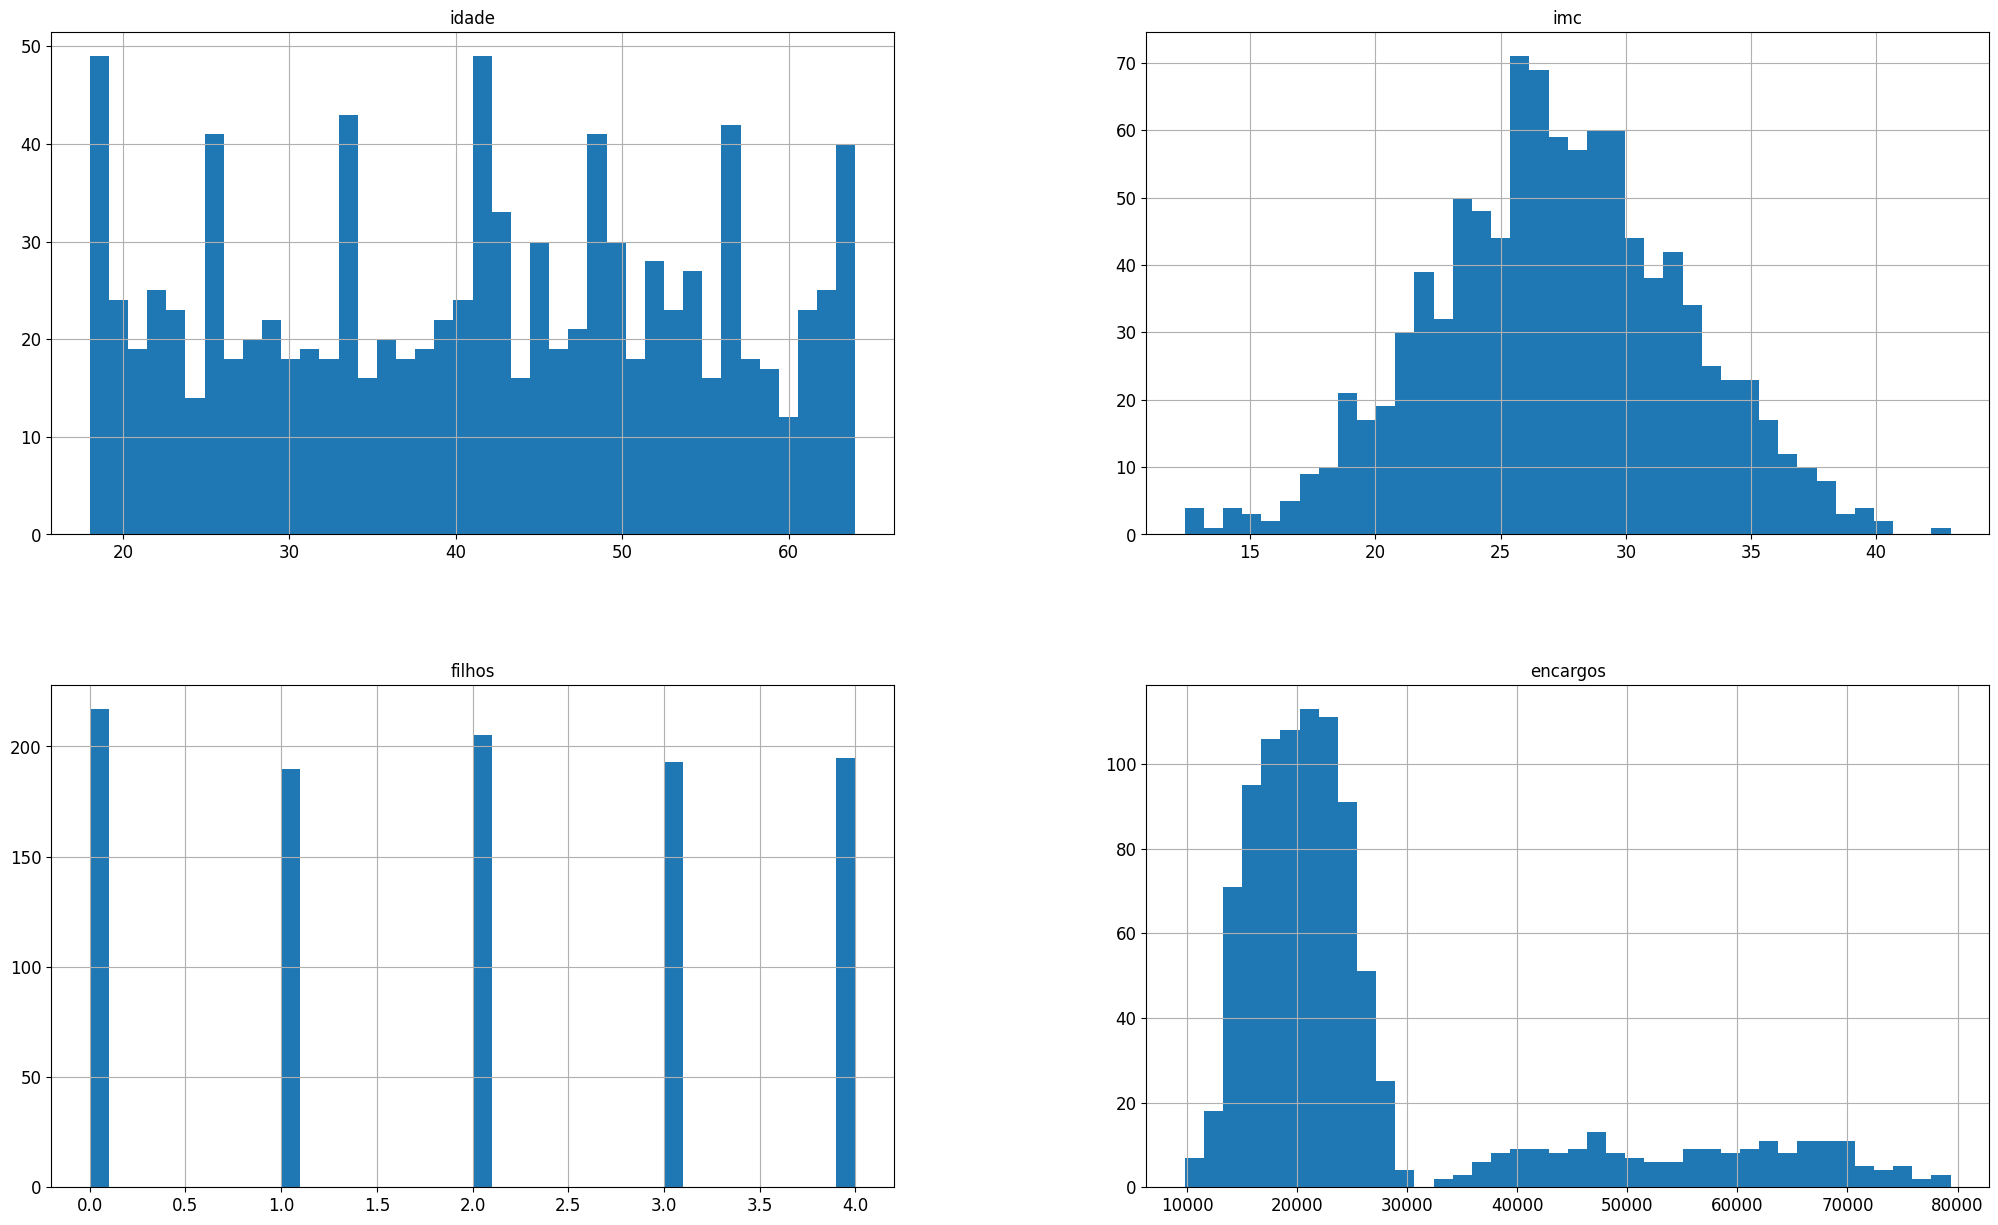

In [12]:
# Exibe os dados graficamente
import matplotlib.pyplot as plt
dataset.hist(bins=40, figsize=(25,15))

In [ ]:
# 🔹 Eixo X (horizontal):
# Representa os valores possíveis da variável sendo analisada.

# Por exemplo:
# idade: vai de 18 a 64 anos → o eixo X mostra essas faixas de idade.
# imc: mostra os valores de índice de massa corporal, como 20, 25, 30 etc.
# filhos: mostra os números inteiros 0, 1, 2, 3, 4.
# encargos: valores em reais (R$) cobrados pelo seguro, como 10.000 até ~80.000.

In [ ]:
# 🔹 Eixo Y (vertical):
# Representa a frequência — ou seja, quantas vezes os valores do eixo X ocorrem no seu dataset.
# Por exemplo:
# Se a barra em idade = 42 atinge Y = 30, significa que 30 pessoas têm 42 anos.
# Se a barra em encargos = 20000 atinge Y = 80, significa que 80 pessoas têm encargos próximos de 20.000.
# Para filhos = 0, se a barra atinge Y = 210, significa que 210 pessoas têm 0 filhos.

In [13]:
# Separando as bases em treino e teste
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(dataset, test_size = 0.2, random_state = 7)

In [14]:
print(len(df_train), "treinamento +", len(df_test), "teste")

800 treinamento + 200 teste


<Axes: >

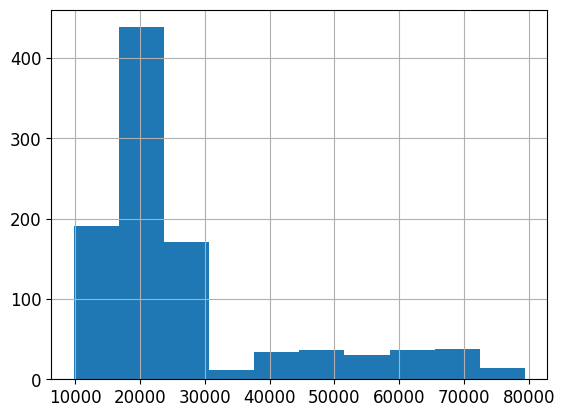

In [15]:
# Exibe a coluna encargos graficamente, podemos notar um peso maior na faixe
# entre 10000 e 30000
dataset["encargos"].hist()

In [ ]:
# Aplicando estratificação para garantir uma boa distribuição de dados

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Criar categorias de encargos para estratificação
dataset['encargo_cat'] = pd.cut(
    dataset['encargos'],
    bins=[0, 15000, 25000, 40000, 60000, np.inf],
    labels=[1, 2, 3, 4, 5]
)

In [17]:
# Agora com a categoria criada, vamos realizar a amostragem estratificada com base na categoria do encargo!
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Aplicar a divisão com base nas faixas de encargo
for train_index, test_index in split.split(dataset, dataset['encargo_cat']):
    df_train = dataset.loc[train_index].copy()
    df_test = dataset.loc[test_index].copy()

In [18]:
# Ver proporção por categoria no conjunto de teste
print("Proporção no conjunto de teste:")
print(df_test['encargo_cat'].value_counts(normalize=True).sort_index())

# Comparar com o original
print("\nProporção no dataset original:")
print(dataset['encargo_cat'].value_counts(normalize=True).sort_index())

Proporção no conjunto de teste:
encargo_cat
1    0.095
2    0.605
3    0.125
4    0.095
5    0.080
Name: proportion, dtype: float64

Proporção no dataset original:
encargo_cat
1    0.093
2    0.603
3    0.126
4    0.097
5    0.081
Name: proportion, dtype: float64


In [19]:
# Remover encargo_cat depois da divisão, colina criada somente para melhor
# distribuição dos dados
for df in (df_train, df_test):
    df.drop('encargo_cat', axis=1, inplace=True)

In [20]:
df_train.head()

,idade,gênero,imc,filhos,fumante,região,encargos
38,24,feminino,26.80,0,não,sudeste,15181.00
127,52,masculino,32.86,0,não,sudeste,23593.27
293,35,feminino,29.07,3,sim,sudoeste,58053.00
836,46,feminino,37.85,4,sim,sudoeste,75010.93
488,33,feminino,34.64,4,não,sudeste,21010.98


In [21]:
df_test.head()

,idade,gênero,imc,filhos,fumante,região,encargos
770,51,masculino,28.75,0,não,noroeste,22871.64
510,61,feminino,30.31,4,não,noroeste,26196.60
946,41,feminino,24.19,4,sim,sudoeste,61896.83
160,49,feminino,26.64,0,sim,sudeste,59558.26
788,55,masculino,30.55,2,não,nordeste,24383.53


In [22]:
# Verificação de nulos.
dataset.isnull().sum()

,0
idade,0
gênero,0
imc,0
filhos,0
fumante,0
região,0
encargos,0
encargo_cat,0


In [ ]:
# Se houvessem valores nulos, iriamos precisar tratar, um exemplo em aula foi
# substituindo os valores nulos pela mediana
# Outra solução em aula foi optar por utilizar classes acessíveis do Sklearn!

In [ ]:
# Pré-processando as categorias

In [23]:
from sklearn.preprocessing import OneHotEncoder

# Selecionar colunas categóricas
cat_cols = ["gênero", "fumante", "região"]
cat_encoder = OneHotEncoder(sparse_output=False)

# Ajustar com o conjunto de treino
X_cat_train = cat_encoder.fit_transform(df_train[cat_cols])
X_cat_test = cat_encoder.transform(df_test[cat_cols])

# Ver as categorias reconhecidas
print(cat_encoder.categories_)

[array(['feminino', 'masculino'], dtype=object), array(['não', 'sim'], dtype=object), array(['nordeste', 'noroeste', 'sudeste', 'sudoeste'], dtype=object)]


In [24]:
X_cat_train[0]

array([1., 0., 1., 0., 0., 0., 1., 0.])

In [ ]:
# Criando a pipeline de pré-processamento dos dados

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [26]:
# Dados numéricos (exceto a variável alvo 'encargos')
num_attribs = ["idade", "imc", "filhos"]

# Dados categóricos (que devem ser transformados com OneHotEncoder)
cat_attribs = ["gênero", "fumante", "região"]

In [27]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())  # não precisamos de imputação porque não há valores nulos
])

In [28]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(drop='first'), cat_attribs)  # usamos drop='first' para evitar multicolinearidade
])

In [29]:
# Aplicando no df_train
X_train_prepared = full_pipeline.fit_transform(df_train)

In [30]:
# Obtem os nomes das colunas numéricas + codificadas
num_features = num_attribs
cat_features = full_pipeline.named_transformers_['cat'].get_feature_names_out(cat_attribs)

# Junta os nomes
all_features = list(num_features) + list(cat_features)

# Cria o DataFrame final
import pandas as pd
X_train_df = pd.DataFrame(X_train_prepared, columns=all_features, index=df_train.index)

# Exibir os primeiros valores
X_train_df.head()

# Note que não temos gênero_masculino e gênero_feminino, ou fumante_sim e fumante_não

,idade,imc,filhos,gênero_masculino,fumante_sim,região_noroeste,região_sudeste,região_sudoeste
38,-1.268697,-0.119188,-1.384015,0.0,0.0,0.0,1.0,0.0
127,0.815405,1.092409,-1.384015,1.0,0.0,0.0,1.0,0.0
293,-0.449943,0.334661,0.702440,0.0,1.0,0.0,0.0,1.0
836,0.368812,2.090076,1.397925,0.0,1.0,0.0,0.0,1.0
488,-0.598807,1.448290,1.397925,0.0,0.0,0.0,1.0,0.0


In [31]:
df_train.loc[[38, 488], ["gênero", "fumante", "região"]]

,gênero,fumante,região
38,feminino,não,sudeste
488,feminino,não,sudeste


In [32]:
X_test_prepared = full_pipeline.transform(df_test)
X_test_df = pd.DataFrame(X_test_prepared, columns=all_features, index=df_test.index)

In [33]:
y_train = df_train["encargos"]
y_test = df_test["encargos"]

In [ ]:
######################################################
# Aplicando LinearRegression para prever os encargos #
######################################################

In [34]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_df, y_train)

LinearRegression()

In [35]:
some_data = df_train.iloc[:5]
some_labels = y_train.iloc[:5]

some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))
print("Real:", list(some_labels))

Predictions: [12992.30277511 24988.35430466 57118.73609501 64521.18718642
 21401.82267992]
Real: [15181.0, 23593.27, 58053.0, 75010.93, 21010.98]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Valores até próximos do esperado.

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_train_preds = lin_reg.predict(X_train_df)

rmse = np.sqrt(mean_squared_error(y_train, y_train_preds))
mae = mean_absolute_error(y_train, y_train_preds)
r2 = r2_score(y_train, y_train_preds)

def calculate_mape(labels, predictions):
    return np.mean(np.abs((labels - predictions) / labels)) * 100

mape = calculate_mape(y_train, y_train_preds)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)
print(f"MAPE: {mape:.2f}%")

RMSE: 3116.420749910316
MAE: 2239.416812383951
R²: 0.9598012807875999
MAPE: 8.38%


In [ ]:
# O modelo erra, em média, cerca de R$3.116,42 no valor dos encargos médicos.
# O modelo erra em média R$2.239,42 para cima ou para baixo.
# O modelo explica ~96% da variação dos encargos com base nas variáveis fornecidas. Excelente resultado!
# O modelo tem um erro médio de 8,38% sobre os valores reais dos encargos.

In [ ]:
# Teste

In [37]:
# Pegando uma linha na base de teste
# Seleciona uma linha real
amostra = df_test.iloc[[0]]  # Note os colchetes duplos para manter formato de DataFrame
valor_real = y_test.iloc[0]

# Pré-processa a amostra
amostra_preparada = full_pipeline.transform(amostra)

# Faz a predição
predito = lin_reg.predict(amostra_preparada)[0]

print(f"Valor real: R${valor_real:.2f}")
print(f"Valor previsto: R${predito:.2f}")

Valor real: R$22871.64
Valor previsto: R$22098.02


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Valor inserido manualmente:

In [38]:
# Criando um dado querente
dado_novo = pd.DataFrame([{
    "idade": 45,
    "gênero": "masculino",
    "imc": 29.5,
    "filhos": 2,
    "fumante": "sim",
    "região": "sudeste"
}])

# Pré-processa o dado com o pipeline
dado_preparado = full_pipeline.transform(dado_novo)

# Faz a predição
predito = lin_reg.predict(dado_preparado)[0]
print(f"Valor previsto para o novo dado: R${predito:.2f}")

Valor previsto para o novo dado: R$58736.06


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Procurando na base valores parecidos com o inventado para ver se a previsão faz sentido:

In [39]:
from sklearn.metrics.pairwise import euclidean_distances

# Pré-processa o dado fictício
dado_proc = full_pipeline.transform(dado_novo)

# Pré-processa todo o dataset original (exceto 'encargos')
dataset_base = dataset.copy()
X_dataset_proc = full_pipeline.transform(dataset_base.drop("encargos", axis=1))

# Calcula a distância da amostra para todo o dataset
distancias = euclidean_distances(X_dataset_proc, dado_proc).flatten()

# Pega os k registros mais próximos
k = 5
indices_mais_proximos = np.argsort(distancias)[:k]
mais_parecidos = dataset.iloc[indices_mais_proximos]

# Exibe os resultados
print(mais_parecidos[["idade", "gênero", "imc", "filhos", "fumante", "região", "encargos"]])
print(f"\nMédia dos encargos semelhantes: R${mais_parecidos['encargos'].mean():.2f}")

     idade     gênero    imc  filhos fumante   região  encargos
139     44  masculino  28.73       1     sim  sudeste  56377.79
351     50  masculino  26.24       1     sim  sudeste  62781.24
522     46  masculino  28.20       2     não  sudeste  22056.87
50      45  masculino  30.93       2     não  sudeste  23412.34
360     41  masculino  28.94       2     não  sudeste  20780.24

Média dos encargos semelhantes: R$37081.70


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


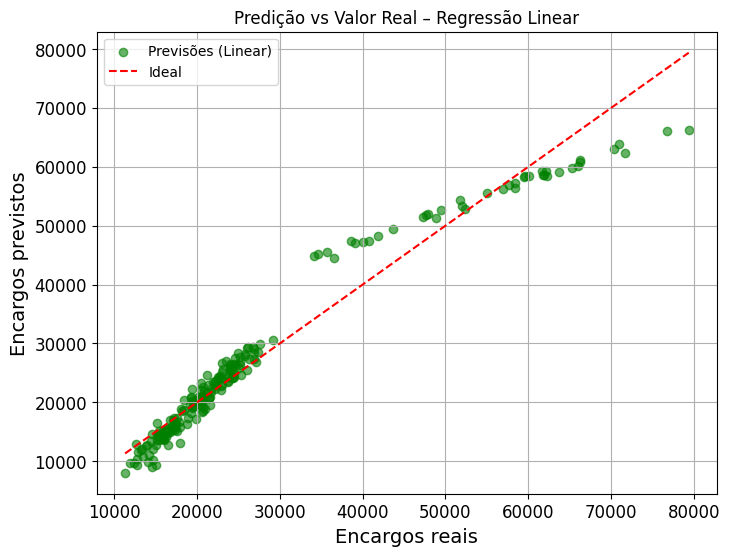

In [40]:
import matplotlib.pyplot as plt

# Gera as previsões com o modelo de Regressão Linear
y_test_pred_lin = lin_reg.predict(X_test_prepared)

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_lin, alpha=0.6, color='green', label='Previsões (Linear)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label='Ideal')
plt.xlabel("Encargos reais")
plt.ylabel("Encargos previstos")
plt.title("Predição vs Valor Real – Regressão Linear")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# O que o gráfico indica:
# A maioria dos pontos está próxima da linha vermelha, o que indica boas previsões.

# Há alguns desvios, especialmente em valores maiores — isso é típico de modelos
# lineares, pois eles não capturam bem não linearidades complexas.

In [ ]:
#############################################
# Agora vamos aplicar DecisionTreeRegressor #
#############################################

In [41]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [42]:
# 1. Cria o modelo com profundidade limitada (evita overfitting)
model_dtr = DecisionTreeRegressor(max_depth=10, random_state=42)

# 2. Treina com seus dados preparados
model_dtr.fit(X_train_prepared, y_train)

# 3. Faz previsões no conjunto de treino
y_train_pred = model_dtr.predict(X_train_prepared)

# 4. Avalia
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

In [43]:
def calculate_mape_tree(labels, predictions):
    errors = np.abs(labels - predictions)
    relative_errors = errors / np.abs(labels)
    mape = np.mean(relative_errors) * 100
    return mape

In [44]:
mape = calculate_mape(y_train, y_train_pred)

# 5. Exibe
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 513.15
MAE: 295.69
R²: 0.9989
MAPE: 1.40%


In [ ]:
# Erro médio quadrático muito baixo. Em média, a predição está a R$513 dos encargos reais.
# Erro médio absoluto baixíssimo: desvio médio de apenas R$295.
# O modelo explica 99.89% da variabilidade dos encargos. É altamente ajustado.
# Erro percentual absoluto médio de apenas 1.4%. Isso é excelente.

# O  modelo de DecisionTreeRegressor com max_depth=10 está com altíssima
# performance no treino, com erros extremamente baixos. Isso indica que o modelo
# aprendeu muito bem os dados de treinamento.

In [ ]:
# Teste

In [45]:
# 1. Selecione uma linha do conjunto de teste original
linha_exemplo = df_test.iloc[[0]]  # Use [[0]] para manter o DataFrame

# 2. Salve o valor real (encargo real)
valor_real = linha_exemplo["encargos"].values[0]

# 3. Remova a coluna alvo para prever com os atributos
linha_exemplo_features = linha_exemplo.drop("encargos", axis=1)

# 4. Aplique o pipeline de pré-processamento
linha_exemplo_preparada = full_pipeline.transform(linha_exemplo_features)

# 5. Faça a previsão com o modelo treinado
previsao = model_dtr.predict(linha_exemplo_preparada)[0]

# 6. Exiba os resultados
print(f"Valor real: R${valor_real:.2f}")
print(f"Valor previsto: R${previsao:.2f}")


Valor real: R$22871.64
Valor previsto: R$22266.49


In [46]:
# 1. Cria o dado fictício
dado_novo = pd.DataFrame([{
    "idade": 45,
    "gênero": "masculino",
    "imc": 29.5,
    "filhos": 2,
    "fumante": "sim",
    "região": "sudeste"
}])

# 2. Pré-processa com o pipeline completo
dado_novo_preparado = full_pipeline.transform(dado_novo)

# 3. Realiza a predição com o modelo de árvore
previsao_dtr = model_dtr.predict(dado_novo_preparado)[0]

# 4. Exibe o resultado
print(f"Valor previsto pelo DecisionTreeRegressor: R${previsao_dtr:.2f}")

Valor previsto pelo DecisionTreeRegressor: R$61906.44


In [ ]:
# Procurando na base valores parecidos com o inventado para ver se a previsão
# também para tree que faz sentido

In [47]:
# Pré-processa o dado fictício
dado_proc = full_pipeline.transform(dado_novo)

# Pré-processa todo o dataset original (exceto 'encargos')
dataset_base = dataset.copy()
X_dataset_proc = full_pipeline.transform(dataset_base.drop("encargos", axis=1))

# Calcula a distância da amostra para todo o dataset
distancias = euclidean_distances(X_dataset_proc, dado_proc).flatten()

# Pega os k registros mais próximos
k = 5
indices_mais_proximos = np.argsort(distancias)[:k]
mais_parecidos = dataset.iloc[indices_mais_proximos]

# Exibe os resultados
print(mais_parecidos[["idade", "gênero", "imc", "filhos", "fumante", "região", "encargos"]])
print(f"\nMédia dos encargos semelhantes: R${mais_parecidos['encargos'].mean():.2f}")

     idade     gênero    imc  filhos fumante   região  encargos
139     44  masculino  28.73       1     sim  sudeste  56377.79
351     50  masculino  26.24       1     sim  sudeste  62781.24
522     46  masculino  28.20       2     não  sudeste  22056.87
50      45  masculino  30.93       2     não  sudeste  23412.34
360     41  masculino  28.94       2     não  sudeste  20780.24

Média dos encargos semelhantes: R$37081.70


In [ ]:
# Poderíamos na busca definir colunas principais, exemplo, fumante, IMC, são valores que
# podem influenciar diretamente no encargo do plano de saúde

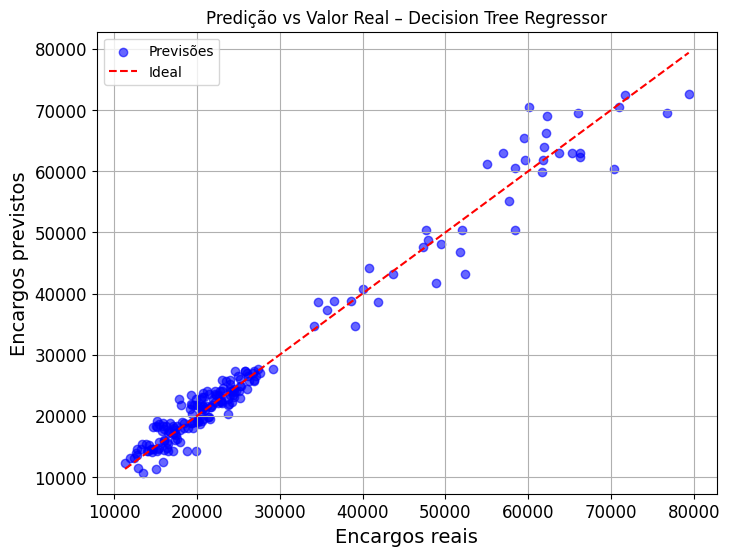

In [48]:
# Gera as previsões no conjunto de teste
y_test_pred = model_dtr.predict(X_test_prepared)

# Gráfico: valores reais vs predições
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue', label='Previsões')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label='Ideal')
plt.xlabel("Encargos reais")
plt.ylabel("Encargos previstos")
plt.title("Predição vs Valor Real – Decision Tree Regressor")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# O que o gráfico mostra:
# A maioria dos pontos estão bem próximos da linha vermelha, o que indica que o
# modelo está prevendo com alta precisão.

# Não há muitos outliers extremos visíveis, o que também é positivo.

In [ ]:
# A regressão linear está indo bem, mas a árvore de decisão foi melhor.
# Tanto visualmente quanto nas métricas.

In [ ]:
# Trabalho feito tirando como base o arquivo Case end to end Regressão da professora.